In [15]:
import pandas as pd

df = pd.read_csv('movies_datset.csv')
df.head()

,movie_name,rating,cast,hotstar,netflix,language,release_year
0,Leo,8.3,"Vijay, Trisha Krishnan, Sanjay Dutt",1,0,Tamil,2023
1,Jawan,8.1,"Shah Rukh Khan, Nayanthara, Vijay Sethupathi",0,1,Hindi,2023
2,Kantara,8.7,"Rishab Shetty, Sapthami Gowda, Kishore",1,0,Kannada,2022
3,RRR,8.9,"N. T. Rama Rao Jr., Ram Charan, Alia Bhatt",0,1,Hindi,2022
4,Master,8.2,"Vijay, Vijay Sethupathi, Malavika Mohanan",1,0,Tamil,2021


## Melt method 

In [17]:
pd.melt(df, value_vars=['hotstar','netflix'])

,variable,value
0,hotstar,1
1,hotstar,0
2,hotstar,1
3,hotstar,0
4,hotstar,1
...,...,...
95,netflix,0
96,netflix,1
97,netflix,0
98,netflix,0


In [18]:
df1 = pd.melt(df, value_vars=['hotstar','netflix'], var_name = 'OTT', value_name= 'Available')
df1

,OTT,Available
0,hotstar,1
1,hotstar,0
2,hotstar,1
3,hotstar,0
4,hotstar,1
...,...,...
95,netflix,0
96,netflix,1
97,netflix,0
98,netflix,0


# AGGREGATE FUNCTIONS

 ### **Creating a new column in the table..**



In [21]:
df['total_platforms'] = df['hotstar'] + df['netflix']
df.head()

,movie_name,rating,cast,hotstar,netflix,language,release_year,total_platforms
0,Leo,8.3,"Vijay, Trisha Krishnan, Sanjay Dutt",1,0,Tamil,2023,1
1,Jawan,8.1,"Shah Rukh Khan, Nayanthara, Vijay Sethupathi",0,1,Hindi,2023,1
2,Kantara,8.7,"Rishab Shetty, Sapthami Gowda, Kishore",1,0,Kannada,2022,1
3,RRR,8.9,"N. T. Rama Rao Jr., Ram Charan, Alia Bhatt",0,1,Hindi,2022,1
4,Master,8.2,"Vijay, Vijay Sethupathi, Malavika Mohanan",1,0,Tamil,2021,1



### **To count the number of records in specific columns..**


In [23]:
df['cast'].count()

50


### **To perform multiple aggregate function on any columns , we can give it in the List form**




In [25]:
df['rating'].agg(['min','max','mean','count'])

min       7.50
max       9.00
mean      8.27
count    50.00
Name: rating, dtype: float64

### **To apply seperate aggregate functions for two seperate columns , we can use dictionary for that**

In [27]:
df.agg({'rating':['min','mean'], 'movie_name' : 'count'})

,rating,movie_name
min,7.50,NaN
mean,8.27,NaN
count,NaN,50.0


# GROUP BY

In [29]:
df.groupby('release_year').agg({'rating':'mean'})

,rating
release_year,
2007,8.900000
2009,8.800000
2011,8.600000
2012,8.400000
2013,7.800000
2014,8.233333
2015,8.700000
2016,8.500000
2017,8.050000


In [30]:
df.groupby('release_year').agg({'rating' : ['max', 'mean'],'movie_name':'count'})

rating           movie_name
                max      mean      count
release_year                            
2007            8.9  8.900000          1
2009            8.8  8.800000          1
2011            8.6  8.600000          1
2012            8.4  8.400000          1
2013            7.8  7.800000          1
2014            8.5  8.233333          3
2015            8.7  8.700000          1
2016            8.8  8.500000          3
2017            8.1  8.050000          2
2018            8.5  8.175000          4
2019            8.6  8.211111          9
2020            8.7  8.266667          3
2021            8.2  7.875000          4
2022            8.9  8.475000          8
2023            9.0  8.162500          8

In [4]:
# downloaded the titanic.csv dataset

import pandas as pd

df = pd.read_csv('titanic.csv')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


### Dropna will drop the rows and colums that has null values..We pass axis here , axis = 1 then it is column if axis = 0 then it is row..
    df.dropna()


In [7]:
df.dropna(axis = 1) # it will drop the null values column by columns

,pclass,name,sex,sibsp,parch,ticket,survived
0,1,"Allen, Miss. Elisabeth Walton",female,0,0,24160,1
1,1,"Allison, Master. Hudson Trevor",male,1,2,113781,1
2,1,"Allison, Miss. Helen Loraine",female,1,2,113781,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,1,2,113781,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,1,2,113781,0
...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,1,0,2665,0
1305,3,"Zabour, Miss. Thamine",female,1,0,2665,0
1306,3,"Zakarian, Mr. Mapriededer",male,0,0,2656,0
1307,3,"Zakarian, Mr. Ortin",male,0,0,2670,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


### To check with the number of unique values in any feature column/ column we will use unique 
    df['name'].unique() -> return an array of unique values..

In [12]:
df['name'].unique()

array(['Allen, Miss. Elisabeth Walton', 'Allison, Master. Hudson Trevor',
       'Allison, Miss. Helen Loraine', ..., 'Zakarian, Mr. Mapriededer',
       'Zakarian, Mr. Ortin', 'Zimmerman, Mr. Leo'], dtype=object)

### Here the name column is not cleaned as it contains the first name , last name or multiple names so we will use str.split() method to 
### split it
    df['name'].str.split(',', expand = True)

In [15]:
df['name'].str.split(',' , expand = True) # Here the name returns two different columns so we will two columns to store it

,0,1
0,Allen,Miss. Elisabeth Walton
1,Allison,Master. Hudson Trevor
2,Allison,Miss. Helen Loraine
3,Allison,Mr. Hudson Joshua Creighton
4,Allison,Mrs. Hudson J C (Bessie Waldo Daniels)
...,...,...
1304,Zabour,Miss. Hileni
1305,Zabour,Miss. Thamine
1306,Zakarian,Mr. Mapriededer
1307,Zakarian,Mr. Ortin


In [17]:
df[['Lname','Fname']]  = df['name'].str.split(',' , expand = True) # Here the name returns two different columns so we will two columns to store it

### Here the name column has been seperated into first name and last name , so we can drop the name column 
        df.drop(columns=['name']

In [20]:
df = df.drop(columns = ['name']) # this will remove the name column from the dataFrame..


In [22]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Fname
0,1,female,29.0000,0,0,24160,211.3375,B5,S,1,Allen,Miss. Elisabeth Walton
1,1,male,0.9167,1,2,113781,151.5500,C22 C26,S,1,Allison,Master. Hudson Trevor
2,1,female,2.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Miss. Helen Loraine
3,1,male,30.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mr. Hudson Joshua Creighton
4,1,female,25.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mrs. Hudson J C (Bessie Waldo Daniels)
...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,female,14.5000,1,0,2665,14.4542,NaN,C,0,Zabour,Miss. Hileni
1305,3,female,NaN,1,0,2665,14.4542,NaN,C,0,Zabour,Miss. Thamine
1306,3,male,26.5000,0,0,2656,7.2250,NaN,C,0,Zakarian,Mr. Mapriededer
1307,3,male,27.0000,0,0,2670,7.2250,NaN,C,0,Zakarian,Mr. Ortin


### Now we want to seperate the title from the Fname so we will again use str.split('.' , expand=True) 

In [25]:
df['Fname'].str.split('.',expand = True, n=1) # Here it also gives the 2 which we can remove using the n=1 after expand.

,0,1
0,Miss,Elisabeth Walton
1,Master,Hudson Trevor
2,Miss,Helen Loraine
3,Mr,Hudson Joshua Creighton
4,Mrs,Hudson J C (Bessie Waldo Daniels)
...,...,...
1304,Miss,Hileni
1305,Miss,Thamine
1306,Mr,Mapriededer
1307,Mr,Ortin


### Assign new columns to it , to makes the changes permanent..
        df[['Title', ' Fname']] = df['fname'].str.split('.',expand = True, n=1)

In [28]:
df[['Title', ' Fname']] = df['Fname'].str.split('.',expand = True, n=1)

In [30]:
df.head()

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Fname,Title,Fname
0,1,female,29.0000,0,0,24160,211.3375,B5,S,1,Allen,Miss. Elisabeth Walton,Miss,Elisabeth Walton
1,1,male,0.9167,1,2,113781,151.5500,C22 C26,S,1,Allison,Master. Hudson Trevor,Master,Hudson Trevor
2,1,female,2.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Miss. Helen Loraine,Miss,Helen Loraine
3,1,male,30.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mr. Hudson Joshua Creighton,Mr,Hudson Joshua Creighton
4,1,female,25.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mrs. Hudson J C (Bessie Waldo Daniels),Mrs,Hudson J C (Bessie Waldo Daniels)


In [32]:
### Now we have the two Fname columns so we will drop one Fname column asssign back to df to make it permanent
df = df.drop(columns=['Fname'])

In [34]:
df.head()

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname
0,1,female,29.0000,0,0,24160,211.3375,B5,S,1,Allen,Miss,Elisabeth Walton
1,1,male,0.9167,1,2,113781,151.5500,C22 C26,S,1,Allison,Master,Hudson Trevor
2,1,female,2.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Miss,Helen Loraine
3,1,male,30.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mr,Hudson Joshua Creighton
4,1,female,25.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mrs,Hudson J C (Bessie Waldo Daniels)


### IN the dataset the Fname and the title column has space in the starting , so to remove the space we will use the strip method..
    df = df['Fname'].str.strip() # assign to df to make it permanent..

In [37]:
df['Fname'] = df[' Fname'].str.strip()
df['Title'] = df['Title'].str.strip()

### Now we have to Make the first letter of the sex column as capital..To do that we will use the capitalize() method 

In [40]:
df['sex'] = df['sex'].str.capitalize()

In [42]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname
0,1,Female,29.0000,0,0,24160,211.3375,B5,S,1,Allen,Miss,Elisabeth Walton,Elisabeth Walton
1,1,Male,0.9167,1,2,113781,151.5500,C22 C26,S,1,Allison,Master,Hudson Trevor,Hudson Trevor
2,1,Female,2.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Miss,Helen Loraine,Helen Loraine
3,1,Male,30.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mr,Hudson Joshua Creighton,Hudson Joshua Creighton
4,1,Female,25.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mrs,Hudson J C (Bessie Waldo Daniels),Hudson J C (Bessie Waldo Daniels)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5000,1,0,2665,14.4542,NaN,C,0,Zabour,Miss,Hileni,Hileni
1305,3,Female,NaN,1,0,2665,14.4542,NaN,C,0,Zabour,Miss,Thamine,Thamine
1306,3,Male,26.5000,0,0,2656,7.2250,NaN,C,0,Zakarian,Mr,Mapriededer,Mapriededer
1307,3,Male,27.0000,0,0,2670,7.2250,NaN,C,0,Zakarian,Mr,Ortin,Ortin


In [44]:
# count the no of family memeber form the data as store it as fam_count...
df['fam_count'] = df['sibsp'] + df['parch']
df.head()

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count
0,1,Female,29.0000,0,0,24160,211.3375,B5,S,1,Allen,Miss,Elisabeth Walton,Elisabeth Walton,0
1,1,Male,0.9167,1,2,113781,151.5500,C22 C26,S,1,Allison,Master,Hudson Trevor,Hudson Trevor,3
2,1,Female,2.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Miss,Helen Loraine,Helen Loraine,3
3,1,Male,30.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mr,Hudson Joshua Creighton,Hudson Joshua Creighton,3
4,1,Female,25.0000,1,2,113781,151.5500,C22 C26,S,0,Allison,Mrs,Hudson J C (Bessie Waldo Daniels),Hudson J C (Bessie Waldo Daniels),3


### Now the price column , round of the price / fare to two digit decimal places

In [47]:
df['fare'] = df['fare'].round(1)


In [49]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count
0,1,Female,29.0000,0,0,24160,211.3,B5,S,1,Allen,Miss,Elisabeth Walton,Elisabeth Walton,0
1,1,Male,0.9167,1,2,113781,151.6,C22 C26,S,1,Allison,Master,Hudson Trevor,Hudson Trevor,3
2,1,Female,2.0000,1,2,113781,151.6,C22 C26,S,0,Allison,Miss,Helen Loraine,Helen Loraine,3
3,1,Male,30.0000,1,2,113781,151.6,C22 C26,S,0,Allison,Mr,Hudson Joshua Creighton,Hudson Joshua Creighton,3
4,1,Female,25.0000,1,2,113781,151.6,C22 C26,S,0,Allison,Mrs,Hudson J C (Bessie Waldo Daniels),Hudson J C (Bessie Waldo Daniels),3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5000,1,0,2665,14.5,NaN,C,0,Zabour,Miss,Hileni,Hileni,1
1305,3,Female,NaN,1,0,2665,14.5,NaN,C,0,Zabour,Miss,Thamine,Thamine,1
1306,3,Male,26.5000,0,0,2656,7.2,NaN,C,0,Zakarian,Mr,Mapriededer,Mapriededer,0
1307,3,Male,27.0000,0,0,2670,7.2,NaN,C,0,Zakarian,Mr,Ortin,Ortin,0


### unique places where deboarding is possible
### s = southampton
### c - cherbourge
### q = Queenstown
   - array(['S', 'C', nan, 'Q'], dtype=object)

In [52]:
df['embarked'].unique()

array(['S', 'C', nan, 'Q'], dtype=object)

### Now we will replace the S, C, and Q with their full names in the dataset...We will use dictionary and then replace this in the df..

In [55]:
d = { 'S':'Southampton', 'C' : 'Cherbourge', 'Q' : 'Queenstown'}
df['embarked'] = df['embarked'].replace(d)

In [57]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count
0,1,Female,29.0000,0,0,24160,211.3,B5,Southampton,1,Allen,Miss,Elisabeth Walton,Elisabeth Walton,0
1,1,Male,0.9167,1,2,113781,151.6,C22 C26,Southampton,1,Allison,Master,Hudson Trevor,Hudson Trevor,3
2,1,Female,2.0000,1,2,113781,151.6,C22 C26,Southampton,0,Allison,Miss,Helen Loraine,Helen Loraine,3
3,1,Male,30.0000,1,2,113781,151.6,C22 C26,Southampton,0,Allison,Mr,Hudson Joshua Creighton,Hudson Joshua Creighton,3
4,1,Female,25.0000,1,2,113781,151.6,C22 C26,Southampton,0,Allison,Mrs,Hudson J C (Bessie Waldo Daniels),Hudson J C (Bessie Waldo Daniels),3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,Female,14.5000,1,0,2665,14.5,NaN,Cherbourge,0,Zabour,Miss,Hileni,Hileni,1
1305,3,Female,NaN,1,0,2665,14.5,NaN,Cherbourge,0,Zabour,Miss,Thamine,Thamine,1
1306,3,Male,26.5000,0,0,2656,7.2,NaN,Cherbourge,0,Zakarian,Mr,Mapriededer,Mapriededer,0
1307,3,Male,27.0000,0,0,2670,7.2,NaN,Cherbourge,0,Zakarian,Mr,Ortin,Ortin,0


### sort the column based on their numberical values we will use
        df.sort_values(by = column_name )

In [60]:
df.sort_values(by = 'ticket', ascending = True)

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count
67,1,Female,30.0,0,0,110152,86.5,B77,Southampton,1,Cherry,Miss,Gladys,Gladys,0
245,1,Female,33.0,0,0,110152,86.5,B77,Southampton,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),of (Lucy Noel Martha Dyer-Edwards),0
195,1,Female,16.0,0,0,110152,86.5,B79,Southampton,1,Maioni,Miss,Roberta,Roberta,0
289,1,Female,18.0,0,2,110413,79.6,E68,Southampton,1,Taussig,Miss,Ruth,Ruth,2
291,1,Female,39.0,1,1,110413,79.6,E67,Southampton,1,Taussig,Mrs,Emil (Tillie Mandelbaum),Emil (Tillie Mandelbaum),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,Female,47.0,1,0,W.E.P. 5734,61.2,E31,Southampton,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),Herbert Fuller (Carrie Constance Toogood),1
62,1,Male,46.0,1,0,W.E.P. 5734,61.2,E31,Southampton,0,Chaffee,Mr,Herbert Fuller,Herbert Fuller,1
433,2,Male,30.0,0,0,W/C 14208,10.5,NaN,Southampton,0,Harris,Mr,Walter,Walter,0
81,1,Male,70.0,1,1,WE/P 5735,71.0,B22,Southampton,0,Crosby,Capt,Edward Gifford,Edward Gifford,2


### If I have to sort it according to multiple columns than we can use df.sort_values(by = ['ticket','age'], ascending = ['True', 'False'])
### Here if the values are same for ticket then it will arrange accorind to the age , also if acending = False then it will do it in descending order 

In [63]:
df = df.sort_values( by = ['ticket', 'age'], ascending = [True, False])

In [65]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count
245,1,Female,33.0,0,0,110152,86.5,B77,Southampton,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),of (Lucy Noel Martha Dyer-Edwards),0
67,1,Female,30.0,0,0,110152,86.5,B77,Southampton,1,Cherry,Miss,Gladys,Gladys,0
195,1,Female,16.0,0,0,110152,86.5,B79,Southampton,1,Maioni,Miss,Roberta,Roberta,0
290,1,Male,52.0,1,1,110413,79.6,E67,Southampton,0,Taussig,Mr,Emil,Emil,2
291,1,Female,39.0,1,1,110413,79.6,E67,Southampton,1,Taussig,Mrs,Emil (Tillie Mandelbaum),Emil (Tillie Mandelbaum),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,Female,47.0,1,0,W.E.P. 5734,61.2,E31,Southampton,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),Herbert Fuller (Carrie Constance Toogood),1
62,1,Male,46.0,1,0,W.E.P. 5734,61.2,E31,Southampton,0,Chaffee,Mr,Herbert Fuller,Herbert Fuller,1
433,2,Male,30.0,0,0,W/C 14208,10.5,NaN,Southampton,0,Harris,Mr,Walter,Walter,0
81,1,Male,70.0,1,1,WE/P 5735,71.0,B22,Southampton,0,Crosby,Capt,Edward Gifford,Edward Gifford,2


In [67]:
df = df.reset_index(drop = True) # The index is disaligned so it will reset the index values and drop the old index column..

### If we have to check how many passengers have the same ticket number, so we will use the value_counts() , that will give the frequency of tickets.

In [70]:
df['ticket'].value_counts() # this gives me output in the series form to get it into table form use reset_index()

ticket
CA. 2343    11
1601         8
CA 2144      8
3101295      7
347077       7
            ..
342826       1
343095       1
343120       1
343271       1
349223       1
Name: count, Length: 929, dtype: int64

In [72]:
df['ticket'].value_counts().reset_index() # this gives me output in the series form to get it into table form use reset_index()

,ticket,count
0,CA. 2343,11
1,1601,8
2,CA 2144,8
3,3101295,7
4,347077,7
...,...,...
924,342826,1
925,343095,1
926,343120,1
927,343271,1


In [74]:
df['ticket'].value_counts().reset_index( name = 'passengerNo')  # to rename the count column name give name = 'passengerNo' in the reset_index()

,ticket,passengerNo
0,CA. 2343,11
1,1601,8
2,CA 2144,8
3,3101295,7
4,347077,7
...,...,...
924,342826,1
925,343095,1
926,343120,1
927,343271,1


In [76]:
# store this table in another dataframe..
ticket_pass = df['ticket'].value_counts().reset_index( name = 'passengerNo') 

In [78]:
ticket_pass

,ticket,passengerNo
0,CA. 2343,11
1,1601,8
2,CA 2144,8
3,3101295,7
4,347077,7
...,...,...
924,342826,1
925,343095,1
926,343120,1
927,343271,1


In [80]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count
0,1,Female,33.0,0,0,110152,86.5,B77,Southampton,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),of (Lucy Noel Martha Dyer-Edwards),0
1,1,Female,30.0,0,0,110152,86.5,B77,Southampton,1,Cherry,Miss,Gladys,Gladys,0
2,1,Female,16.0,0,0,110152,86.5,B79,Southampton,1,Maioni,Miss,Roberta,Roberta,0
3,1,Male,52.0,1,1,110413,79.6,E67,Southampton,0,Taussig,Mr,Emil,Emil,2
4,1,Female,39.0,1,1,110413,79.6,E67,Southampton,1,Taussig,Mrs,Emil (Tillie Mandelbaum),Emil (Tillie Mandelbaum),2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.2,E31,Southampton,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),Herbert Fuller (Carrie Constance Toogood),1
1305,1,Male,46.0,1,0,W.E.P. 5734,61.2,E31,Southampton,0,Chaffee,Mr,Herbert Fuller,Herbert Fuller,1
1306,2,Male,30.0,0,0,W/C 14208,10.5,NaN,Southampton,0,Harris,Mr,Walter,Walter,0
1307,1,Male,70.0,1,1,WE/P 5735,71.0,B22,Southampton,0,Crosby,Capt,Edward Gifford,Edward Gifford,2


## Merge Function 

### syntax 
> pd.merge(table1,table2, on = 'common_column', how = 'inner/ outer/ left/ right')

### when the common columns name is different in two table then use this syntax..

> pd.merge(table1,table2, left_on = 'common_column', right_on = 'common_col', how = 'inner/ outer/ left/ right')


In [83]:
df = pd.merge(df, ticket_pass, on = 'ticket', how = 'inner') # make it permanent by assigning to df

In [85]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count,passengerNo
0,1,Female,33.0,0,0,110152,86.5,B77,Southampton,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),of (Lucy Noel Martha Dyer-Edwards),0,3
1,1,Female,30.0,0,0,110152,86.5,B77,Southampton,1,Cherry,Miss,Gladys,Gladys,0,3
2,1,Female,16.0,0,0,110152,86.5,B79,Southampton,1,Maioni,Miss,Roberta,Roberta,0,3
3,1,Male,52.0,1,1,110413,79.6,E67,Southampton,0,Taussig,Mr,Emil,Emil,2,3
4,1,Female,39.0,1,1,110413,79.6,E67,Southampton,1,Taussig,Mrs,Emil (Tillie Mandelbaum),Emil (Tillie Mandelbaum),2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,61.2,E31,Southampton,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),Herbert Fuller (Carrie Constance Toogood),1,2
1305,1,Male,46.0,1,0,W.E.P. 5734,61.2,E31,Southampton,0,Chaffee,Mr,Herbert Fuller,Herbert Fuller,1,2
1306,2,Male,30.0,0,0,W/C 14208,10.5,NaN,Southampton,0,Harris,Mr,Walter,Walter,0,1
1307,1,Male,70.0,1,1,WE/P 5735,71.0,B22,Southampton,0,Crosby,Capt,Edward Gifford,Edward Gifford,2,2


### We want to find whether the person is travelling alone or with family or friends....

In [88]:

df['fare'] = (df['fare']/ df['passengerNo']).round(1) # it will create the fare by each head..

def comp_type(row):
    f = row['fam_count']
    p = row['passengerNo']

    if p == 1:
        return 'solo'
    elif f == 0 and p>1:
        return 'friends'
    else: 
        return 'family'
    

In [90]:
# it is not applied to the data  , we will use the apply function to apply 

In [92]:
df['companion_type'] = df.apply(comp_type, axis = 1) # Here comp_type is user defined function.

### In the age columns  we have to display age _category , whethe they are children or adult..

In [96]:
def age_cat(row):

    if age > 0 and age <= 2:
        return 'infant'
    elif age > 2 and age <= 16:
        return 'child'
    elif age > 16 and age <= 25:
        return 'teen'
    elif age > 25 and age <= 59:
        return 'adult'
    elif age > 59 and age <= 100:
        return 'senior citizen'


### instead of these code we can use the cut function , when we have range of continious values..



### instead of these code we can use the cut function , when we have range of continious values..

### syntax = pd.cut(data, bins[], labels = [])

pd.cut(df['age'], bins=[0,2,16,25,59,100] , labels = ['infant', 'child', 'teen','adult','senior citizen'])

### Here , bins 0 is excluded and 2 is included, similarly , 2 is exluded and 16 is included in child..
### cut is inbuilt pandas method , which can only be used for continious numerical values..where bins decides the range 

In [99]:
df['age_cat'] = pd.cut(df['age'], bins=[0,2,16,25,59,100] , labels = ['infant', 'child', 'teen','adult','senior citizen'])

In [101]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count,passengerNo,companion_type,age_cat
0,1,Female,33.0,0,0,110152,28.8,B77,Southampton,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),of (Lucy Noel Martha Dyer-Edwards),0,3,friends,adult
1,1,Female,30.0,0,0,110152,28.8,B77,Southampton,1,Cherry,Miss,Gladys,Gladys,0,3,friends,adult
2,1,Female,16.0,0,0,110152,28.8,B79,Southampton,1,Maioni,Miss,Roberta,Roberta,0,3,friends,child
3,1,Male,52.0,1,1,110413,26.5,E67,Southampton,0,Taussig,Mr,Emil,Emil,2,3,family,adult
4,1,Female,39.0,1,1,110413,26.5,E67,Southampton,1,Taussig,Mrs,Emil (Tillie Mandelbaum),Emil (Tillie Mandelbaum),2,3,family,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,30.6,E31,Southampton,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),Herbert Fuller (Carrie Constance Toogood),1,2,family,adult
1305,1,Male,46.0,1,0,W.E.P. 5734,30.6,E31,Southampton,0,Chaffee,Mr,Herbert Fuller,Herbert Fuller,1,2,family,adult
1306,2,Male,30.0,0,0,W/C 14208,10.5,NaN,Southampton,0,Harris,Mr,Walter,Walter,0,1,solo,adult
1307,1,Male,70.0,1,1,WE/P 5735,35.5,B22,Southampton,0,Crosby,Capt,Edward Gifford,Edward Gifford,2,2,family,senior citizen


In [103]:
df['Title'].unique()

array(['the Countess', 'Miss', 'Mr', 'Mrs', 'Dr', 'Major', 'Master',
       'Col', 'Lady', 'Jonkheer', 'Rev', 'Ms', 'Mme', 'Mlle', 'Sir',
       'Don', 'Dona', 'Capt'], dtype=object)

### Now Based on the title we are going to classify whether the person is in 'Military' or common person or the royal person....

In [106]:
Royal = ['the Countess', 'Jonkheer', 'Don', 'Dona', 'Master','Sir']
Common = ['Miss', 'Mr', 'Mrs', 'Lady','Ms', 'Mme', 'Mile']
Military = ['Major', 'Col','Capt']
other_professional = ['Dr','Rev']

In [108]:
def social_status(row):

    c = row['Title']

    if c in Royal:
        return 'Royal'
    elif c in Common:
        return 'Common'
    elif c in Military:
        return 'Military'
    elif c in other_professional:
        return 'Other Professional'

# we will use apply function ..to apply to the data 

df['social status'] = df.apply(social_status, axis = 1)

In [110]:
df

,pclass,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived,Lname,Title,Fname,Fname,fam_count,passengerNo,companion_type,age_cat,social status
0,1,Female,33.0,0,0,110152,28.8,B77,Southampton,1,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards),of (Lucy Noel Martha Dyer-Edwards),0,3,friends,adult,Royal
1,1,Female,30.0,0,0,110152,28.8,B77,Southampton,1,Cherry,Miss,Gladys,Gladys,0,3,friends,adult,Common
2,1,Female,16.0,0,0,110152,28.8,B79,Southampton,1,Maioni,Miss,Roberta,Roberta,0,3,friends,child,Common
3,1,Male,52.0,1,1,110413,26.5,E67,Southampton,0,Taussig,Mr,Emil,Emil,2,3,family,adult,Common
4,1,Female,39.0,1,1,110413,26.5,E67,Southampton,1,Taussig,Mrs,Emil (Tillie Mandelbaum),Emil (Tillie Mandelbaum),2,3,family,adult,Common
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Female,47.0,1,0,W.E.P. 5734,30.6,E31,Southampton,1,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood),Herbert Fuller (Carrie Constance Toogood),1,2,family,adult,Common
1305,1,Male,46.0,1,0,W.E.P. 5734,30.6,E31,Southampton,0,Chaffee,Mr,Herbert Fuller,Herbert Fuller,1,2,family,adult,Common
1306,2,Male,30.0,0,0,W/C 14208,10.5,NaN,Southampton,0,Harris,Mr,Walter,Walter,0,1,solo,adult,Common
1307,1,Male,70.0,1,1,WE/P 5735,35.5,B22,Southampton,0,Crosby,Capt,Edward Gifford,Edward Gifford,2,2,family,senior citizen,Military


### Here the columns are not arranged in systematic order..so we will do that 



In [113]:
df.columns

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin',
       'embarked', 'survived', 'Lname', 'Title', ' Fname', 'Fname',
       'fam_count', 'passengerNo', 'companion_type', 'age_cat',
       'social status'],
      dtype='object')

In [115]:
col_list = ['pclass', 'Title', 'Fname', 'Lname','sibsp', 'parch', 'sex','age','fare','ticket', 
            'embarked', 'fam_count', 'passengerNo','companion_type','age_cat','social status','survived']

In [117]:
### Assign the Variable to df and then assign to df to make ti permanent..

df = df[col_list]


In [119]:
df

,pclass,Title,Fname,Lname,sibsp,parch,sex,age,fare,ticket,embarked,fam_count,passengerNo,companion_type,age_cat,social status,survived
0,1,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,0,0,Female,33.0,28.8,110152,Southampton,0,3,friends,adult,Royal,1
1,1,Miss,Gladys,Cherry,0,0,Female,30.0,28.8,110152,Southampton,0,3,friends,adult,Common,1
2,1,Miss,Roberta,Maioni,0,0,Female,16.0,28.8,110152,Southampton,0,3,friends,child,Common,1
3,1,Mr,Emil,Taussig,1,1,Male,52.0,26.5,110413,Southampton,2,3,family,adult,Common,0
4,1,Mrs,Emil (Tillie Mandelbaum),Taussig,1,1,Female,39.0,26.5,110413,Southampton,2,3,family,adult,Common,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,1,0,Female,47.0,30.6,W.E.P. 5734,Southampton,1,2,family,adult,Common,1
1305,1,Mr,Herbert Fuller,Chaffee,1,0,Male,46.0,30.6,W.E.P. 5734,Southampton,1,2,family,adult,Common,0
1306,2,Mr,Walter,Harris,0,0,Male,30.0,10.5,W/C 14208,Southampton,0,1,solo,adult,Common,0
1307,1,Capt,Edward Gifford,Crosby,1,1,Male,70.0,35.5,WE/P 5735,Southampton,2,2,family,senior citizen,Military,0


In [121]:
# Univariate plot , which plots graph using  the one varible or one column..ex -pie chart ,count plot..

import matplotlib.pyplot as plt

c = df['companion_type'].value_counts() # gives the frequency of each type..

# we can we cansee the values and index of it..

print(c.values)
print(c.index)



[713 469 127]
Index(['solo', 'family', 'friends'], dtype='object', name='companion_type')


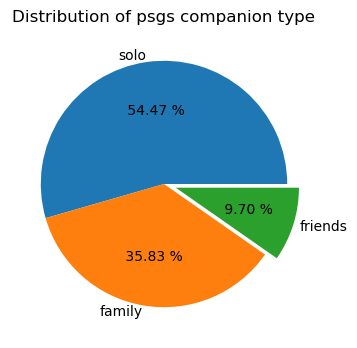

In [123]:
## Now plotting the pie chart...

plt.figure(figsize = (4,4))
# plt.pie(x = c.values, labels = c.index, autopct='% .2f %%',explode = (0, 0, 0.2)) 

# plt.pie(x = c.values, labels = c.index, autopct='% .2f %%',explode = (0, 0, 0.2), labeldistance = 0.2) # took it inside 

plt.pie(x = c.values, labels = c.index, autopct='% .2f %%',explode = (0, 0, 0.1), labeldistance = 1.05, pctdistance = 0.6) # took it inside 



## pie take three inputs..( x = c.values, labels = '' , autopct = '% .2f %%')
## use explode to separate any slices. and then we have labeldistance , and pctdistance inside the pie 

plt.title('Distribution of psgs companion type')

plt.show()

In [126]:
e = df['embarked'].value_counts()
print(e.values)
print(e.index)

[914 270 123]
Index(['Southampton', 'Cherbourge', 'Queenstown'], dtype='object', name='embarked')


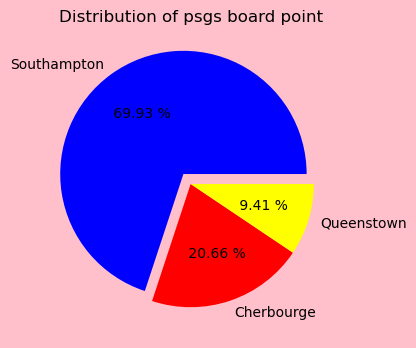

In [128]:
## plotting the pie chart..

plt.figure(figsize = (4,4), facecolor = 'pink')
plt.title('Distribution of psgs board point')

plt.pie(x=e.values, labels = e.index, autopct = '% .2f %%', explode = (0.1,0,0), colors = ['blue', 'red', 'yellow'])
plt.show()

In [ ]:
## conclusion..
# Most of the passengers are boarding from the southapmpton than other places 

## Bivariate plot 
### BarPlot..

- Bar plot is used  with the categorical data and then numerical data
- it is used to checking the relation between the two columns
- it will always returns the aggregate values..

#### we have two data here 
- 1) Categorical Data and
- 2) Numerical Data..

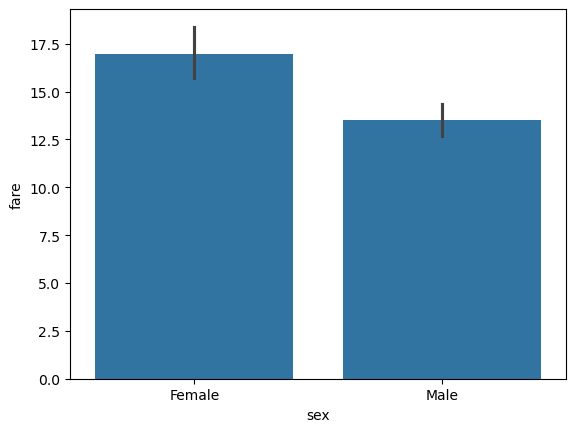

In [137]:
import seaborn as sns

# Syntax of barplot .. sns.barplot( data = , x-axis= '' ,y-axis = '')
# By default it returns the aggregate values..

sns.barplot(data = df, x = 'sex', y = 'fare')
plt.show()

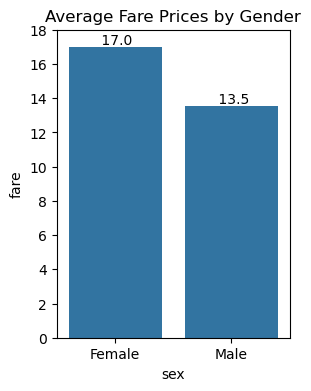

In [208]:
## to remove the black color error bar from the above table..
plt.figure(figsize = (3,4))
plt.title('Average Fare Prices by Gender')

# sns.barplot(data = df, x = 'sex', y = 'fare', errorbar=None)

 ##  estimator = 'min'/'max'/ 'mean'  is used to estimate or plot the fare

bar = sns.barplot(data = df, x = 'sex', y = 'fare', errorbar=None,estimator = 'mean')

## to provide a label on the bar plot , use the bar.bar_label( bar.containers[0])

## here fmt '% .lf' : It is used to format the numerical values..

bar.bar_label(bar.containers[0], fmt = '% .1lf')

plt.yticks(range(0,20,2))
plt.show()


## conclusion : the Avg prices of fare paid by females is 17.0 greater than avg of fare prices paid by males which is 13.5

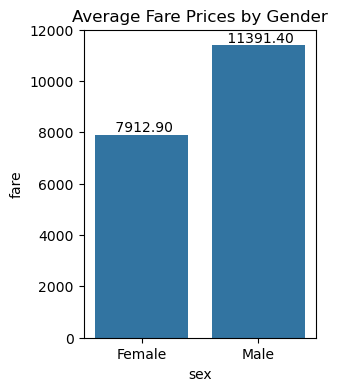

In [212]:
## when the estimator is sum

plt.figure(figsize = (3,4))
plt.title('Average Fare Prices by Gender')

## Estimator = 'min'/'max'/ 'mean'  is used to estimate or plot the fare

bar = sns.barplot(data = df, x = 'sex', y = 'fare', errorbar=None,estimator = 'sum')
bar.bar_label(bar.containers[0], fmt = '% .2lf')

plt.yticks(range(0,14000,2000))
plt.show()

## conclusion :: Here the total sum of fare paid by males are 11391.40 which is way greater than female sum of fare = 7912.90

### Use the bar plot by using the age_category.., and numerical column fare .. find out who is paying high avg of fare..

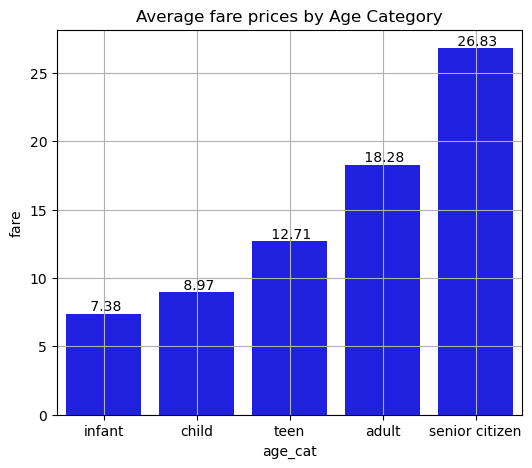

In [252]:
plt.figure(figsize = (6,5))
plt.title('Average fare prices by Age Category')
b = sns.barplot(data = df , x = 'age_cat', y = 'fare', errorbar = None, color = 'blue')

## showing the labels..
b.bar_label(b.containers[0], fmt = '% .2lf')

plt.grid()
plt.show()

## conclusion : Here the senior citizens are paying the higher avg fare prices.

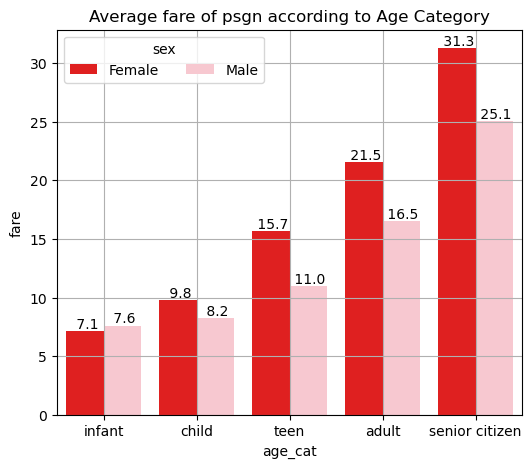

In [297]:
### If we need a subcategory inside the catergory use the hue ='column' and to change color use palette = ['color1', 'color2']

plt.figure(figsize = (6,5))
plt.title('Average fare of psgn according to Age Category')

b = sns.barplot(data = df , x = 'age_cat', y = 'fare', errorbar = None,hue = 'sex', palette = ['red', 'pink'])

## showing the labels..
# b.bar_label(b.containers[0] , fmt = '% .2lf') : # this will apply the label on only one bar , to apply on every bar use the loop.

for i in b.containers:
    b.bar_label(i, fmt = '% .1lf')
    
    

## to change the position of legend.. we can use mthod called  loc = "" inside the 
# plt.legend(loc = "")

## best will fill the empty space available.. 
## ncol = 2 is used to create the n number of columns..
## We can give title using the title parameter

plt.legend(loc = 'best' , ncol = 2, title = 'sex') 

plt.grid()
plt.show()


## conclusion : The avg fare is increasing as the age increases..
### Except the infants, the avg fare paid by females in each age category is more than the males 
